# Pair-bias structural pattern analysis

Measures four properties of `pair_bias` tensors captured from MegaFold's Pairformer stack:

1. **Symmetry** — can we store only the upper triangle?
2. **Spatial sparsity** — are there dead 64x64 tiles to skip?
3. **Temporal reuse** — does block k+1 look like block k?
4. **Cross-head correlation** — do heads carry redundant information?

Each property gets a plot, a summary statistic, and a `STRONG` / `MODERATE` / `WEAK` verdict.

Run the capture first, e.g.:

```
bash scripts/capture_pair_bias_structured.sh
```


## 1. Imports and setup

In [2]:
import re
from collections import defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch

%matplotlib inline
plt.rcParams["figure.dpi"] = 110

CAPTURE_PATH = Path("../outputs/pair_bias_structured/run.pt")
print("Capture path:", CAPTURE_PATH.resolve())

Capture path: /home/rtae/MegaFold/outputs/pair_bias_structured/run.pt


## 2. Load and organize captured tensors

Keys from the capture script look like:
- `pairformer.layers.2.1.fn.to_attn_bias [AttentionPairBias]`
- `pairformer.layers.2.0.tri_attn_starting.fn.to_attn_bias [TriangleAttention]`

We scope to `pairformer.layers` (the main 48-block stack) and parse `(block_idx, layer_type)`.


In [3]:
data = torch.load(CAPTURE_PATH, map_location="cpu")
print(f"Loaded {len(data)} capture points from {CAPTURE_PATH}")
print("Example keys:")
for k in list(data.keys())[:4]:
    print(f"  {k}")

# Keys look like:
#   "pairformer.layers.2.1.fn.to_attn_bias [AttentionPairBias]"
#   "pairformer.layers.2.0.tri_attn_starting.fn.to_attn_bias [TriangleAttention]"
# The class name is embedded in square brackets at the end by capture_pair_bias_structured.py.

LAYER_PATTERNS = [
    ("pair_bias_attn",    re.compile(r"\[AttentionPairBias\]")),
    ("tri_attn_starting", re.compile(r"tri_attn_starting")),
    ("tri_attn_ending",   re.compile(r"tri_attn_ending")),
]

PAIRFORMER_SCOPES = [
    "pairformer.layers",
    "confidence_head.pairformer_stack.layers",
    "template_embedder.pairformer_stack",
]

DIFFUSION_SCOPES = {
    "token_transformer": "diffusion_module.token_transformer.layers",
    "atom_encoder": "diffusion_module.atom_encoder.layers",
    "atom_decoder": "diffusion_module.atom_decoder.layers",
}

AUX_SCOPES = [
    "input_embedder.atom_transformer.layers",
    "msa_module.layers",
]

ALL_SCOPES = sorted(
    PAIRFORMER_SCOPES + list(DIFFUSION_SCOPES.values()) + AUX_SCOPES,
    key=len,
    reverse=True,
)


def extract_block_idx(name: str, scope: str) -> int | None:
    suffix = name[len(scope):].lstrip(".")
    match = re.match(r"(\d+)", suffix)
    return int(match.group(1)) if match else None


def parse_name(name: str):
    scope = next((s for s in ALL_SCOPES if name.startswith(s)), None)
    if scope is None:
        return None, None, None

    block_idx = extract_block_idx(name, scope)
    if block_idx is None:
        return scope, None, None

    for label, pat in LAYER_PATTERNS:
        if pat.search(name):
            return scope, block_idx, label
    return scope, block_idx, "other"


# by_scope[scope][layer_type][block_idx] = tensor
by_scope: dict = defaultdict(lambda: defaultdict(dict))
for name, tensor in data.items():
    scope, idx, ltype = parse_name(name)
    if scope is None or idx is None:
        continue
    by_scope[scope][ltype][idx] = tensor.float()

print("\nAvailable scopes:")
for scope in sorted(by_scope):
    parts = []
    for ltype, blocks in by_scope[scope].items():
        example = next(iter(blocks.values()))
        parts.append(f"{ltype}: {len(blocks)} blocks, shape {tuple(example.shape)}")
    print(f"  {scope}")
    for part in parts:
        print(f"    {part}")

# Pick the main Pairformer scope for all subsequent analysis.
SCOPE = next((s for s in PAIRFORMER_SCOPES if s in by_scope), next(iter(by_scope)))
print(f"\nUsing scope: '{SCOPE}'")
for ltype, blocks in by_scope[SCOPE].items():
    example = next(iter(blocks.values()))
    print(f"  {ltype}: {len(blocks)} blocks, shape {tuple(example.shape)}")

# Flat alias used by the rest of the notebook: by_layer[layer_type][block_idx]
by_layer: dict[str, dict[int, torch.Tensor]] = by_scope[SCOPE]


Loaded 69 capture points from ../outputs/pair_bias_structured/run.pt
Example keys:
  input_embedder.atom_transformer.layers.0.2.fn.to_attn_bias [AttentionPairBias]
  input_embedder.atom_transformer.layers.1.2.fn.to_attn_bias [AttentionPairBias]
  input_embedder.atom_transformer.layers.2.2.fn.to_attn_bias [AttentionPairBias]
  template_embedder.pairformer_stack.0.tri_attn_starting.fn.to_attn_bias [TriangleAttention]

Available scopes:
  confidence_head.pairformer_stack.layers
    tri_attn_starting: 4 blocks, shape (1, 4, 31, 31)
    tri_attn_ending: 4 blocks, shape (1, 4, 31, 31)
    pair_bias_attn: 4 blocks, shape (1, 16, 31, 31)
  diffusion_module.atom_decoder.layers
    pair_bias_attn: 3 blocks, shape (1, 4, 10, 27, 54)
  diffusion_module.atom_encoder.layers
    pair_bias_attn: 3 blocks, shape (1, 4, 10, 27, 54)
  diffusion_module.token_transformer.layers
    pair_bias_attn: 24 blocks, shape (1, 16, 31, 31)
  input_embedder.atom_transformer.layers
    pair_bias_attn: 3 blocks, shape 

In [4]:
def as_hnn(B: torch.Tensor) -> torch.Tensor:
    """Normalize a captured pair-bias tensor to shape [H, N, N]."""
    t = B.float()
    # Drop leading singleton batch dims while 3+ extra axes remain in front of (H, N, N).
    while t.dim() > 3 and t.shape[0] == 1:
        t = t.squeeze(0)
    if t.dim() == 5:
        t = t.reshape(-1, t.shape[-2], t.shape[-1])[: t.shape[-3]]
    if t.dim() == 4:
        t = t.reshape(-1, t.shape[-2], t.shape[-1])
    if t.dim() != 3:
        raise ValueError(f"Expected 3D [H, N, N], got {tuple(B.shape)}")
    return t


sample_ltype = next(iter(by_layer))
sample = next(iter(by_layer[sample_ltype].values()))
print("Sample normalized shape:", tuple(as_hnn(sample).shape))

Sample normalized shape: (4, 31, 31)


## 3. Property 1 — Symmetry

$$\text{sym\_ratio}(B) = \frac{\|B_{\text{sym}}\|_F^2}{\|B_{\text{sym}}\|_F^2 + \|B_{\text{anti}}\|_F^2}$$

- STRONG if > 0.9, MODERATE if > 0.7, WEAK otherwise.

tri_attn_starting: mean=0.931, min=0.877, max=0.953
tri_attn_ending: mean=0.900, min=0.844, max=0.950
pair_bias_attn: mean=0.982, min=0.970, max=0.995


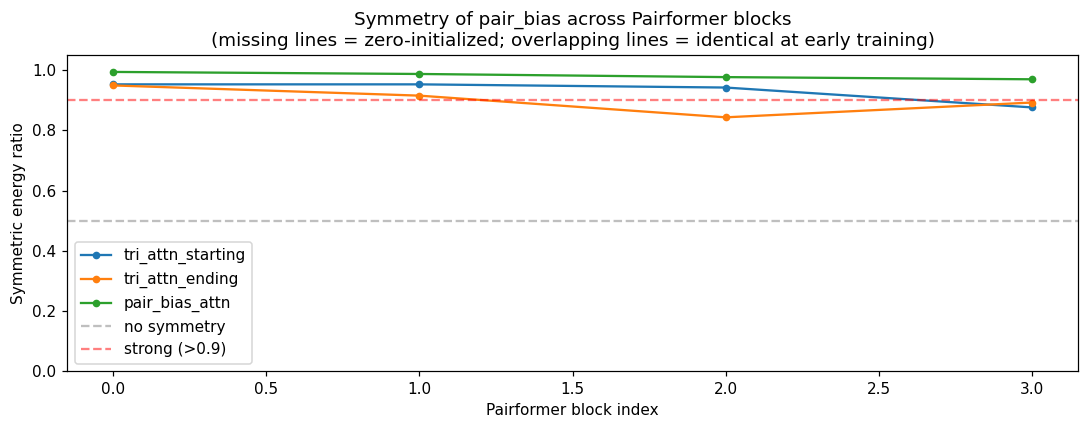

In [5]:
def symmetry_ratio(B: torch.Tensor) -> float:
    t = as_hnn(B)
    if t.shape[-1] != t.shape[-2]:
        return float("nan")  # windowed (atom) attention — skip
    sym = 0.5 * (t + t.transpose(-2, -1))
    anti = 0.5 * (t - t.transpose(-2, -1))
    sym_e = (sym ** 2).sum().item()
    anti_e = (anti ** 2).sum().item()
    denom = sym_e + anti_e
    return sym_e / denom if denom > 0 else float("nan")


fig, ax = plt.subplots(figsize=(10, 4))
sym_summary: dict[str, list[float]] = {}
for ltype, blocks in by_layer.items():
    xs = sorted(blocks.keys())
    ys = [symmetry_ratio(blocks[k]) for k in xs]
    pairs = [(x, y) for x, y in zip(xs, ys) if not np.isnan(y)]
    if not pairs:
        print(f"{ltype}: all NaN — tensor is likely all-zeros (zero-initialized weight, too few training steps)")
        continue
    xs_plot, ys_plot = zip(*pairs)
    ax.plot(xs_plot, ys_plot, "o-", label=ltype, markersize=4)
    sym_summary[ltype] = list(ys_plot)
    print(f"{ltype}: mean={np.mean(ys_plot):.3f}, min={min(ys_plot):.3f}, max={max(ys_plot):.3f}")

ax.axhline(0.5, color="gray", linestyle="--", alpha=0.5, label="no symmetry")
ax.axhline(0.9, color="red", linestyle="--", alpha=0.5, label="strong (>0.9)")
ax.set_xlabel("Pairformer block index")
ax.set_ylabel("Symmetric energy ratio")
ax.set_ylim(0, 1.05)
ax.legend()
ax.set_title("Symmetry of pair_bias across Pairformer blocks\n"
             "(missing lines = zero-initialized; overlapping lines = identical at early training)")
plt.tight_layout()
plt.show()


PER-HEAD SYMMETRY — pair_bias_attn
Analyzing 4 blocks from scope 'pairformer.layers'.
Note: this capture comes from the smoke config, so the current Pairformer depth is smaller than the full model.


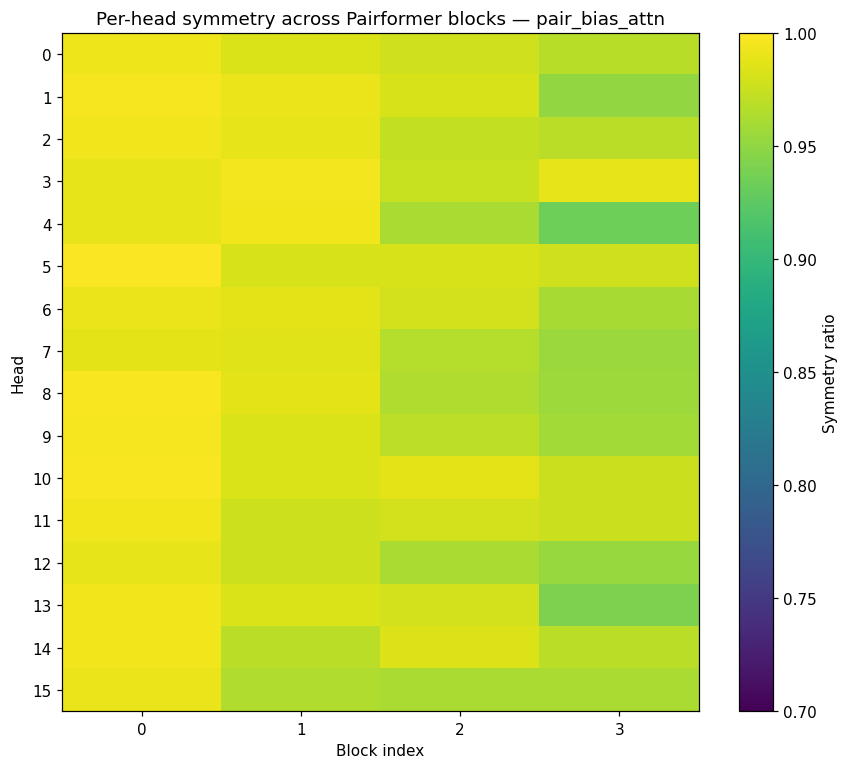

All heads: mean=0.978, std=0.015
Min symmetry anywhere in the grid: 0.934
Per-head means: [0.981 0.98  0.981 0.987 0.969 0.985 0.98  0.973 0.976 0.977 0.986 0.982
 0.971 0.974 0.979 0.97 ]
Per-head mins:  [0.968 0.951 0.968 0.975 0.934 0.978 0.961 0.955 0.956 0.959 0.976 0.976
 0.954 0.941 0.969 0.962]
Per-head maxs:  [0.993 0.996 0.993 0.995 0.993 0.998 0.991 0.987 0.997 0.996 0.997 0.994
 0.989 0.993 0.994 0.991]
Across-head mean spread: 0.017
Interpretation: symmetry is consistent across heads; this supports symmetry as a property of pair_bias, not a per-head artifact.


In [6]:
def per_head_symmetry(B: torch.Tensor) -> list[float]:
    t = as_hnn(B)
    if t.shape[-1] != t.shape[-2]:
        return []
    ratios: list[float] = []
    for h in range(t.shape[0]):
        Bh = t[h]
        sym = 0.5 * (Bh + Bh.T)
        anti = 0.5 * (Bh - Bh.T)
        sym_e = (sym ** 2).sum().item()
        anti_e = (anti ** 2).sum().item()
        denom = sym_e + anti_e
        ratios.append(sym_e / denom if denom > 0 else float("nan"))
    return ratios


def format_head_values(values: np.ndarray) -> str:
    return ", ".join(f"h{h}={v:.3f}" for h, v in enumerate(values) if not np.isnan(v))


target_ltype = "pair_bias_attn" if "pair_bias_attn" in by_layer else next(iter(by_layer))
blocks_sorted = sorted(by_layer[target_ltype].keys())
grid = np.array([per_head_symmetry(by_layer[target_ltype][b]) for b in blocks_sorted], dtype=float)

print("=" * 78)
print(f"PER-HEAD SYMMETRY — {target_ltype}")
print("=" * 78)
print(f"Analyzing {len(blocks_sorted)} blocks from scope '{SCOPE}'.")
if len(blocks_sorted) < 48:
    print("Note: this capture comes from the smoke config, so the current Pairformer depth is smaller than the full model.")

if grid.size == 0 or np.isnan(grid).all():
    print("Per-head symmetry unavailable: tensors are non-square or still zero-initialized.")
else:
    per_head_pairformer_summary = {
        "layer_type": target_ltype,
        "blocks": blocks_sorted,
        "grid": grid,
        "overall_mean": float(np.nanmean(grid)),
        "overall_std": float(np.nanstd(grid)),
        "min_any": float(np.nanmin(grid)),
        "per_head_means": np.nanmean(grid, axis=0),
        "per_head_mins": np.nanmin(grid, axis=0),
        "per_head_maxs": np.nanmax(grid, axis=0),
    }

    fig, ax = plt.subplots(
        figsize=(max(8, len(blocks_sorted) * 0.7), max(3.5, grid.shape[1] * 0.35 + 1.5))
    )
    im = ax.imshow(grid.T, aspect="auto", cmap="viridis", vmin=0.7, vmax=1.0)
    plt.colorbar(im, ax=ax, label="Symmetry ratio")
    ax.set_xticks(range(len(blocks_sorted)))
    ax.set_xticklabels(blocks_sorted)
    ax.set_yticks(range(grid.shape[1]))
    ax.set_yticklabels(range(grid.shape[1]))
    ax.set_xlabel("Block index")
    ax.set_ylabel("Head")
    ax.set_title(f"Per-head symmetry across Pairformer blocks — {target_ltype}")
    plt.tight_layout()
    plt.show()

    overall_mean = per_head_pairformer_summary["overall_mean"]
    overall_std = per_head_pairformer_summary["overall_std"]
    min_any = per_head_pairformer_summary["min_any"]
    per_head_means = per_head_pairformer_summary["per_head_means"]
    per_head_mins = per_head_pairformer_summary["per_head_mins"]
    per_head_maxs = per_head_pairformer_summary["per_head_maxs"]
    spread = float(np.nanmax(per_head_means) - np.nanmin(per_head_means))
    low_heads = [h for h, v in enumerate(per_head_means) if not np.isnan(v) and v < 0.9]

    print(f"All heads: mean={overall_mean:.3f}, std={overall_std:.3f}")
    print(f"Min symmetry anywhere in the grid: {min_any:.3f}")
    print(f"Per-head means: {np.round(per_head_means, 3)}")
    print(f"Per-head mins:  {np.round(per_head_mins, 3)}")
    print(f"Per-head maxs:  {np.round(per_head_maxs, 3)}")
    print(f"Across-head mean spread: {spread:.3f}")

    if not low_heads and spread < 0.03:
        print("Interpretation: symmetry is consistent across heads; this supports symmetry as a property of pair_bias, not a per-head artifact.")
    elif len(low_heads) <= max(1, grid.shape[1] // 8):
        print(f"Interpretation: most heads are strongly symmetric, with a small number of weaker heads worth separate handling: {low_heads}")
    else:
        print("Interpretation: symmetry is materially head-dependent; a symmetry-aware kernel would need per-head logic.")


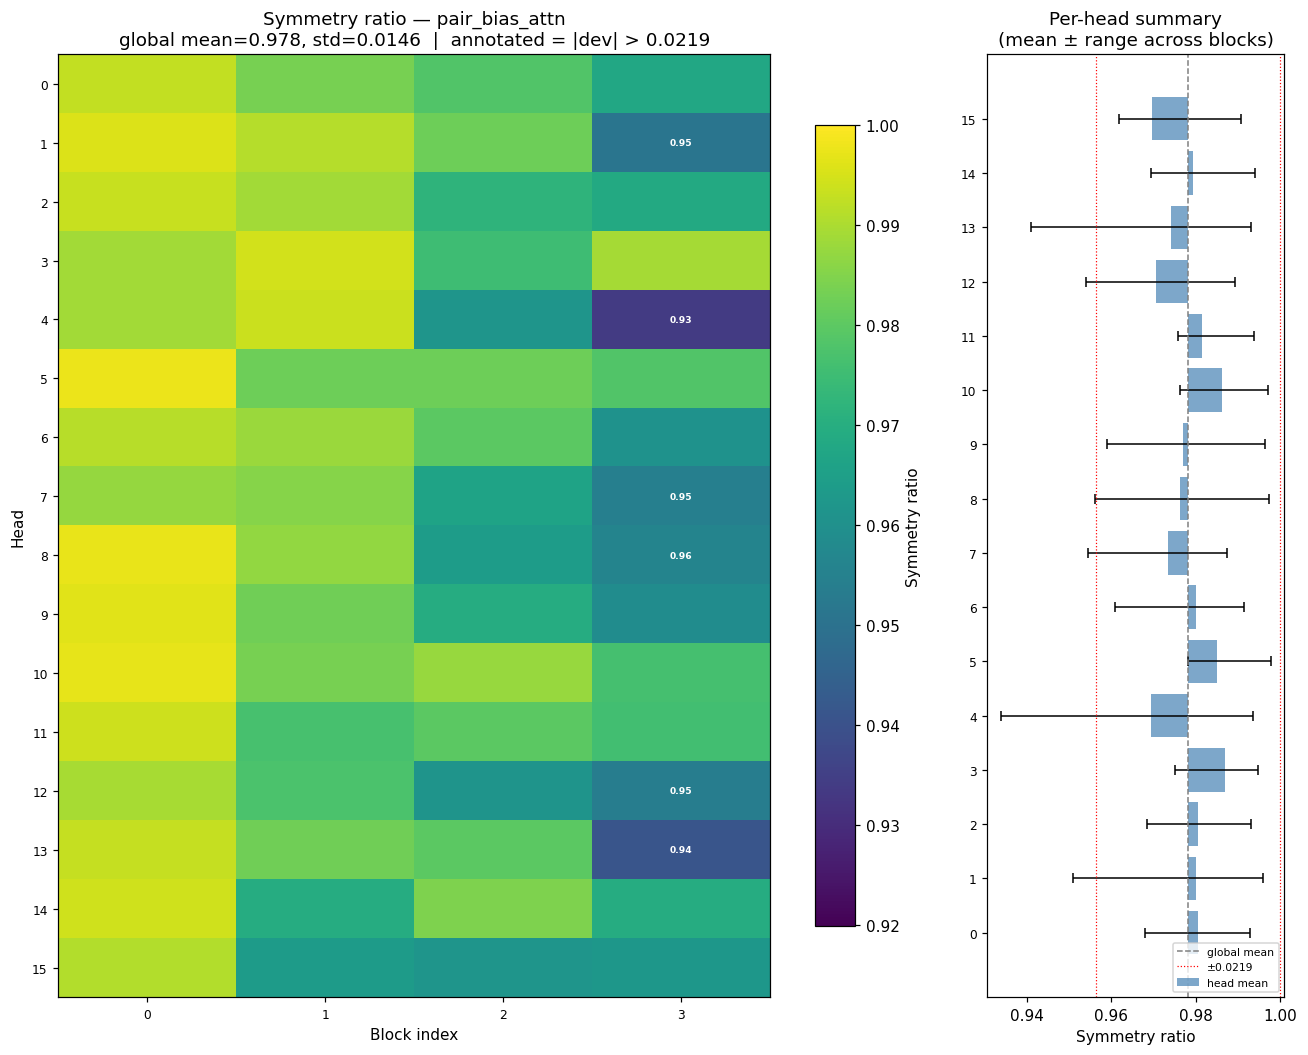


Outlier cells (|dev| > 0.0219 from mean 0.978):
  block= 3, head=4: sym=0.9339  (dev=-0.0443)
  block= 3, head=13: sym=0.9409  (dev=-0.0373)
  block= 3, head=1: sym=0.9509  (dev=-0.0273)
  block= 3, head=12: sym=0.9540  (dev=-0.0242)
  block= 3, head=7: sym=0.9546  (dev=-0.0236)
  block= 3, head=8: sym=0.9561  (dev=-0.0220)


In [7]:

# Symmetry deviation heatmap — all captured pair_bias_attn blocks
# Highlights any head or block that deviates from the overall pattern.

_ltype = "pair_bias_attn"
_blocks = sorted(by_layer[_ltype].keys())
_grid = np.array([per_head_symmetry(by_layer[_ltype][b]) for b in _blocks], dtype=float)  # [B, H]

if _grid.size == 0 or np.isnan(_grid).all():
    print("No square pair_bias_attn tensors found — cannot build symmetry heatmap.")
else:
    _mean = float(np.nanmean(_grid))
    _std  = float(np.nanstd(_grid))
    _dev  = _grid - _mean          # deviation from global mean
    _thresh = max(1.5 * _std, 0.005)   # flag if |dev| > threshold

    fig, axes = plt.subplots(
        1, 2,
        figsize=(max(12, len(_blocks) * 0.75 + 4), max(4, _grid.shape[1] * 0.45 + 2.5)),
        gridspec_kw={"width_ratios": [3, 1]},
    )

    # ── Left panel: absolute symmetry ratio ──────────────────────────────────
    ax = axes[0]
    vlo, vhi = max(0.0, _mean - 4 * _std), min(1.0, _mean + 4 * _std)
    im0 = ax.imshow(_grid.T, aspect="auto", cmap="viridis", vmin=vlo, vmax=vhi)
    plt.colorbar(im0, ax=ax, label="Symmetry ratio", shrink=0.85)

    # Annotate outlier cells
    B, H = _grid.shape
    for b in range(B):
        for h in range(H):
            v = _grid[b, h]
            if not np.isnan(v) and abs(v - _mean) > _thresh:
                ax.text(b, h, f"{v:.2f}", ha="center", va="center",
                        fontsize=6, color="white" if v < _mean else "black",
                        fontweight="bold")

    ax.set_xticks(range(len(_blocks)))
    ax.set_xticklabels(_blocks, fontsize=8)
    ax.set_yticks(range(_grid.shape[1]))
    ax.set_yticklabels(range(_grid.shape[1]), fontsize=8)
    ax.set_xlabel("Block index")
    ax.set_ylabel("Head")
    ax.set_title(
        f"Symmetry ratio — pair_bias_attn\n"
        f"global mean={_mean:.3f}, std={_std:.4f}  |  annotated = |dev| > {_thresh:.4f}"
    )

    # ── Right panel: per-head mean ± range ───────────────────────────────────
    ax2 = axes[1]
    _ph_mean = np.nanmean(_grid, axis=0)
    _ph_min  = np.nanmin(_grid,  axis=0)
    _ph_max  = np.nanmax(_grid,  axis=0)
    heads = np.arange(_grid.shape[1])
    ax2.barh(heads, _ph_mean - _mean, left=_mean, color="steelblue", alpha=0.7, label="head mean")
    ax2.errorbar(
        _ph_mean, heads,
        xerr=[_ph_mean - _ph_min, _ph_max - _ph_mean],
        fmt="none", color="black", linewidth=1, capsize=3,
    )
    ax2.axvline(_mean, color="gray", linestyle="--", linewidth=1, label=f"global mean")
    ax2.axvline(_mean - _thresh, color="red", linestyle=":", linewidth=0.8)
    ax2.axvline(_mean + _thresh, color="red", linestyle=":", linewidth=0.8, label=f"±{_thresh:.4f}")
    ax2.set_yticks(heads)
    ax2.set_yticklabels(heads, fontsize=8)
    ax2.set_xlabel("Symmetry ratio")
    ax2.set_title("Per-head summary\n(mean ± range across blocks)")
    ax2.legend(fontsize=7, loc="lower right")

    plt.tight_layout()
    plt.show()

    # ── Textual deviation report ──────────────────────────────────────────────
    outlier_cells = [(b_idx, h, _grid[bi, h])
                     for bi, b_idx in enumerate(_blocks)
                     for h in range(H)
                     if not np.isnan(_grid[bi, h]) and abs(_grid[bi, h] - _mean) > _thresh]
    if outlier_cells:
        print(f"\nOutlier cells (|dev| > {_thresh:.4f} from mean {_mean:.3f}):")
        for b_idx, h, v in sorted(outlier_cells, key=lambda x: abs(x[2] - _mean), reverse=True):
            print(f"  block={b_idx:2d}, head={h}: sym={v:.4f}  (dev={v - _mean:+.4f})")
    else:
        print(f"\nNo outlier cells — all (block, head) pairs within {_thresh:.4f} of mean {_mean:.3f}.")
        print("Symmetry is uniform across all captured pair_bias_attn blocks and heads.")


Plotting block=3, head=4  |  shape=(31, 31), sym_ratio=0.9339


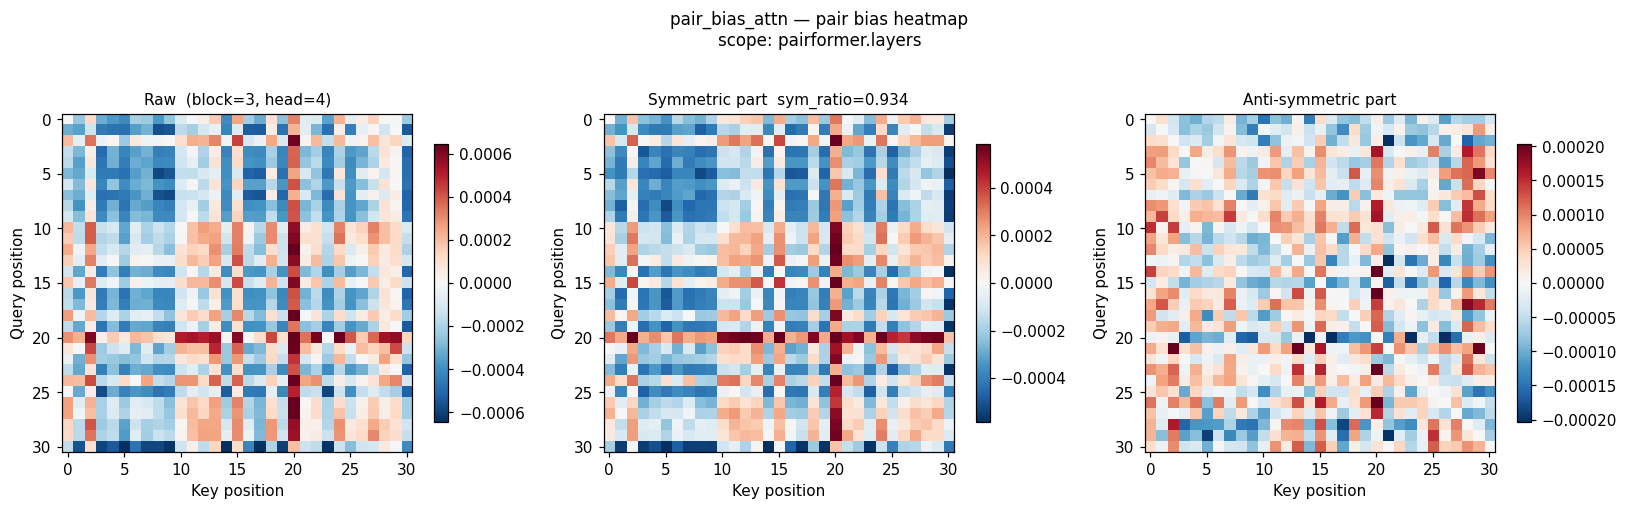

In [8]:

# ── Sample one (block, head) and plot the raw bias heatmap ───────────────────
# Defaults: the block/head with the largest deviation from the symmetry mean.
# Override by setting SAMPLE_BLOCK and SAMPLE_HEAD below.

SAMPLE_BLOCK = None   # e.g. 3  — set to None for auto (largest deviation)
SAMPLE_HEAD  = None   # e.g. 0  — set to None for auto (largest deviation)

_ltype = "pair_bias_attn"
_blocks_s = sorted(by_layer[_ltype].keys())

# Auto-select the (block, head) with maximum |deviation| from mean
if SAMPLE_BLOCK is None or SAMPLE_HEAD is None:
    if outlier_cells:
        _auto_b, _auto_h, _ = max(outlier_cells, key=lambda x: abs(x[2] - _mean))
    else:
        # No outliers: pick the median block, head 0
        _auto_b = _blocks_s[len(_blocks_s) // 2]
        _auto_h = 0
    if SAMPLE_BLOCK is None:
        SAMPLE_BLOCK = _auto_b
    if SAMPLE_HEAD is None:
        SAMPLE_HEAD = _auto_h

_B_raw = as_hnn(by_layer[_ltype][SAMPLE_BLOCK])   # [H, N, N]
_Bh    = _B_raw[SAMPLE_HEAD]                        # [N, N]
_sym_h  = 0.5 * (_Bh + _Bh.T)
_anti_h = 0.5 * (_Bh - _Bh.T)
_sym_r  = float(((_sym_h ** 2).sum() / ((_Bh ** 2).sum() + 1e-12)).item())

print(f"Plotting block={SAMPLE_BLOCK}, head={SAMPLE_HEAD}  |  "
      f"shape={tuple(_Bh.shape)}, sym_ratio={_sym_r:.4f}")

_vabs = float(_Bh.abs().quantile(0.99).item())

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for ax_, data_, title_ in [
    (axes[0], _Bh,     f"Raw  (block={SAMPLE_BLOCK}, head={SAMPLE_HEAD})"),
    (axes[1], _sym_h,  f"Symmetric part  sym_ratio={_sym_r:.3f}"),
    (axes[2], _anti_h, "Anti-symmetric part"),
]:
    _v = float(data_.abs().quantile(0.99).item()) or 1e-6
    im_ = ax_.imshow(data_.numpy(), cmap="RdBu_r", vmin=-_v, vmax=_v, aspect="auto")
    plt.colorbar(im_, ax=ax_, shrink=0.82)
    ax_.set_title(title_, fontsize=10)
    ax_.set_xlabel("Key position")
    ax_.set_ylabel("Query position")

plt.suptitle(f"pair_bias_attn — pair bias heatmap\n"
             f"scope: {SCOPE}", fontsize=11, y=1.02)
plt.tight_layout()
plt.show()


## 4. Property 2 — Spatial sparsity (64x64 tiles)

Partition each `[N, N]` into 64x64 tiles, compute per-tile mean absolute value, and count
tiles whose magnitude is below 10% of the median tile. STRONG if mean fraction > 0.30.

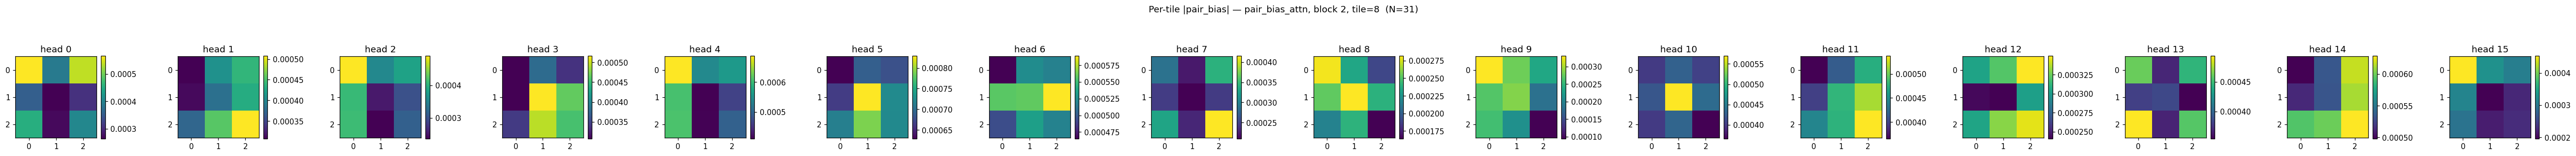

Spatial sparsity — fraction of tiles below 10% of median:
  mean = 0.00%,  range = 0.00% – 0.00%


In [28]:
def choose_tile_size(N: int) -> int:
    """Pick the largest power-of-2 tile size that fits at least a 2x2 grid."""
    for ts in (64, 32, 16, 8, 4):
        if N >= ts * 2:
            return ts
    return max(1, N // 2)


def tile_magnitude_map(B: torch.Tensor, tile_size: int | None = None) -> torch.Tensor | None:
    t = as_hnn(B)
    H, N, M = t.shape
    if N != M:
        return None
    ts = tile_size if tile_size is not None else choose_tile_size(N)
    if N < ts * 2:
        return None
    n_tiles = N // ts
    Nc = n_tiles * ts
    t = t[:, :Nc, :Nc]
    tiles = t.reshape(H, n_tiles, ts, n_tiles, ts)
    return tiles.abs().mean(dim=(-3, -1))


# Heatmap visualization: pair_bias_attn at middle block, all heads.
target_ltype = "pair_bias_attn" if "pair_bias_attn" in by_layer else next(iter(by_layer))
blocks = by_layer[target_ltype]
mid_idx = sorted(blocks.keys())[len(blocks) // 2]
B_mid = blocks[mid_idx]
N = as_hnn(B_mid).shape[-1]
ts = choose_tile_size(N)
tm = tile_magnitude_map(B_mid, tile_size=ts)

if tm is not None:
    H = tm.shape[0]
    fig, axes = plt.subplots(1, H, figsize=(3 * H, 3.2), squeeze=False)
    for h in range(H):
        im = axes[0, h].imshow(tm[h].numpy(), cmap="viridis")
        axes[0, h].set_title(f"head {h}")
        plt.colorbar(im, ax=axes[0, h], fraction=0.046)
    plt.suptitle(f"Per-tile |pair_bias| — {target_ltype}, block {mid_idx}, tile={ts}  (N={N})")
    plt.tight_layout()
    plt.show()
else:
    print(f"{target_ltype} block {mid_idx}: N={N} too small for any tile grid; skipping heatmap.")

# Aggregate low-magnitude tile fractions across all blocks of the chosen layer type.
sparsity_fracs: list[float] = []
for idx, B in blocks.items():
    tm = tile_magnitude_map(B)
    if tm is None:
        continue
    median = tm.median()
    if median == 0:
        sparsity_fracs.append(float("nan"))
        continue
    sparsity_fracs.append((tm < median * 0.1).float().mean().item())

valid = [f for f in sparsity_fracs if not np.isnan(f)]
if valid:
    print(
        f"Spatial sparsity — fraction of tiles below 10% of median:\n"
        f"  mean = {np.mean(valid):.2%},  range = {min(valid):.2%} – {max(valid):.2%}"
    )
else:
    print(f"Sparsity skipped: N={N}, need N >= {choose_tile_size(N)*2} for tile analysis.\n"
          f"Re-run capture with a larger crop_size (e.g. crop_size: 256 in the config).")


## 5. Property 3 — Temporal reuse across Pairformer blocks

$$\delta_k = \frac{\|B_{k+1} - B_k\|_F}{\|B_k\|_F}$$

STRONG if median < 0.1, MODERATE if < 0.3, WEAK otherwise.

tri_attn_starting: mean=1.330, median=1.367
tri_attn_ending: mean=1.364, median=1.402
pair_bias_attn: mean=1.413, median=1.435


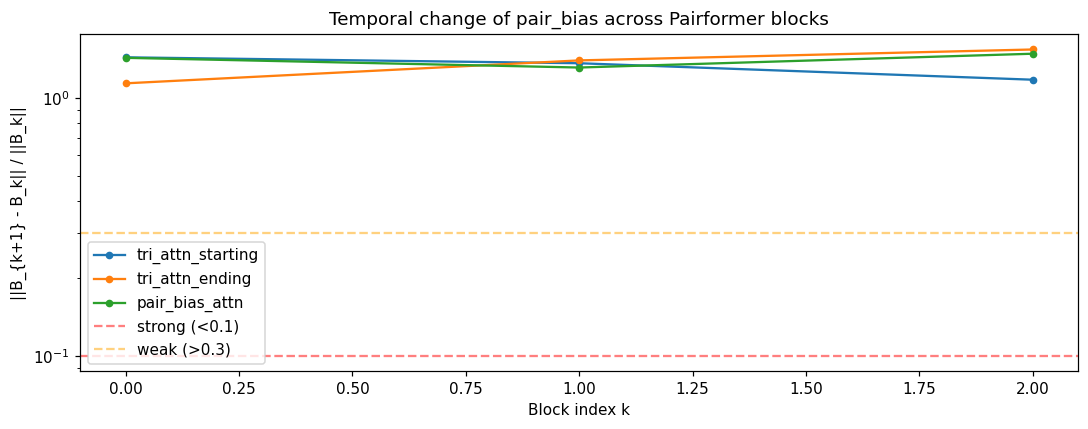

In [29]:
def temporal_deltas(block_dict: dict[int, torch.Tensor]) -> list[tuple[int, float]]:
    keys = sorted(block_dict.keys())
    out: list[tuple[int, float]] = []
    for k, k_next in zip(keys[:-1], keys[1:]):
        B_k = as_hnn(block_dict[k])
        B_next = as_hnn(block_dict[k_next])
        if B_k.shape != B_next.shape:
            continue
        base = B_k.norm().item()
        if base == 0:
            continue
        diff = (B_next - B_k).norm().item()
        out.append((k, diff / base))
    return out


fig, ax = plt.subplots(figsize=(10, 4))
temporal_summary: dict[str, list[float]] = {}
for ltype, blocks in by_layer.items():
    deltas = temporal_deltas(blocks)
    if not deltas:
        continue
    xs, ys = zip(*deltas)
    ax.plot(xs, ys, "o-", label=ltype, markersize=4)
    temporal_summary[ltype] = list(ys)
    print(f"{ltype}: mean={np.mean(ys):.3f}, median={np.median(ys):.3f}")

ax.axhline(0.1, color="red", linestyle="--", alpha=0.5, label="strong (<0.1)")
ax.axhline(0.3, color="orange", linestyle="--", alpha=0.5, label="weak (>0.3)")
ax.set_yscale("log")
ax.set_xlabel("Block index k")
ax.set_ylabel("||B_{k+1} - B_k|| / ||B_k||")
ax.set_title("Temporal change of pair_bias across Pairformer blocks")
ax.legend()
plt.tight_layout()
plt.show()

## 6. Property 4 — Cross-head correlation

Flatten each head to a vector, mean-center, L2-normalize, compute `H x H` Pearson
correlation matrix, average across blocks. STRONG if mean off-diagonal > 0.8.

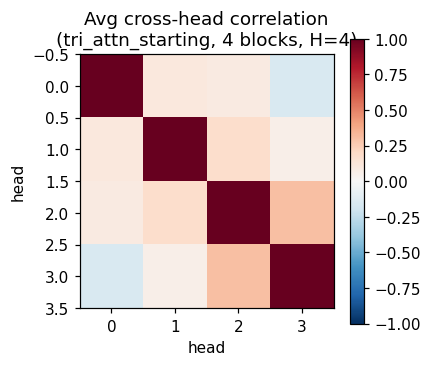

tri_attn_starting: mean off-diagonal correlation = 0.097


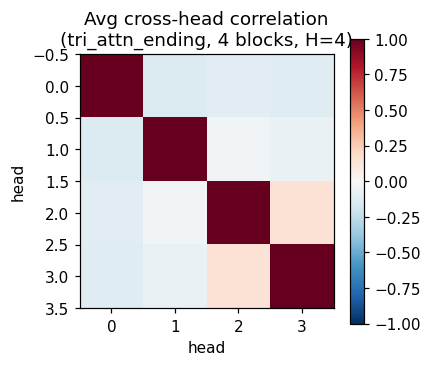

tri_attn_ending: mean off-diagonal correlation = -0.051


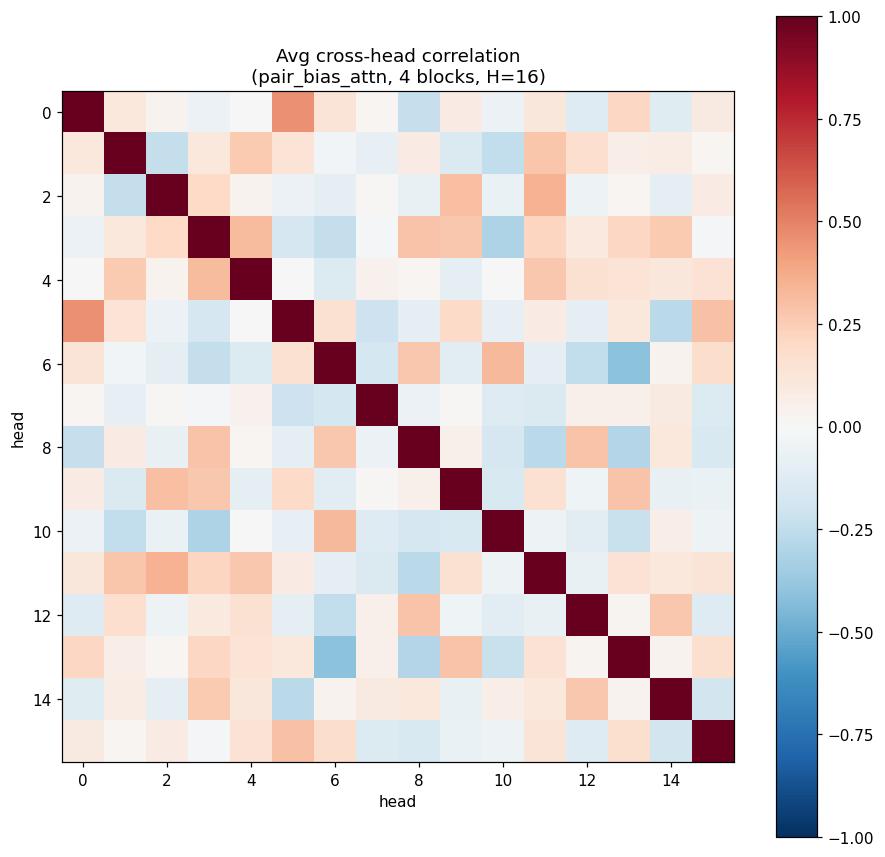

pair_bias_attn: mean off-diagonal correlation = 0.021


In [30]:
def head_correlation_matrix(B: torch.Tensor) -> torch.Tensor | None:
    t = as_hnn(B)
    H = t.shape[0]
    if H < 2:
        return None
    flat = t.reshape(H, -1)
    flat = flat - flat.mean(dim=1, keepdim=True)
    norms = flat.norm(dim=1, keepdim=True)
    if (norms == 0).any():
        return None
    normalized = flat / norms
    return normalized @ normalized.T


mean_off_corr_by_ltype: dict[str, float] = {}

for target_ltype, ltype_blocks in by_layer.items():
    corrs = []
    for B in ltype_blocks.values():
        c = head_correlation_matrix(B)
        if c is not None:
            corrs.append(c)

    if not corrs:
        print(f"{target_ltype}: skipped (all-zero or H<2)")
        mean_off_corr_by_ltype[target_ltype] = float("nan")
        continue

    H_min = min(c.shape[0] for c in corrs)
    stacked = torch.stack([c[:H_min, :H_min] for c in corrs])
    avg_corr = stacked.mean(dim=0)

    fig, ax = plt.subplots(figsize=(max(4, H_min * 0.4 + 2), max(3.5, H_min * 0.4 + 1.5)))
    im = ax.imshow(avg_corr.numpy(), cmap="RdBu_r", vmin=-1, vmax=1)
    plt.colorbar(im, ax=ax)
    ax.set_xlabel("head")
    ax.set_ylabel("head")
    ax.set_title(f"Avg cross-head correlation\n({target_ltype}, {len(corrs)} blocks, H={H_min})")
    plt.tight_layout()
    plt.show()

    mask = 1 - torch.eye(H_min)
    mean_off = ((avg_corr * mask).sum() / mask.sum()).item()
    mean_off_corr_by_ltype[target_ltype] = mean_off
    print(f"{target_ltype}: mean off-diagonal correlation = {mean_off:.3f}")

# Expose the main pairformer pair_bias value for the summary cell.
mean_off_corr = mean_off_corr_by_ltype.get(
    "pair_bias_attn",
    next(iter(mean_off_corr_by_ltype.values()), float("nan")),
)


## 7. Summary and decision

Combined verdict for the `pair_bias_attn` layer type (the outer Pairformer attention).

In [31]:
def classify(value: float, strong: float, moderate: float, higher_is_stronger: bool) -> str:
    if np.isnan(value):
        return "N/A (zero-init / insufficient data)"
    if higher_is_stronger:
        return "STRONG" if value >= strong else ("MODERATE" if value >= moderate else "WEAK")
    else:
        return "STRONG" if value <= strong else ("MODERATE" if value <= moderate else "WEAK")


print("=" * 78)
print("STRUCTURAL PROPERTY SUMMARY  (per layer type)")
print("=" * 78)

for target_ltype, ltype_blocks in by_layer.items():
    sym_vals = [v for v in (symmetry_ratio(B) for B in ltype_blocks.values()) if not np.isnan(v)]
    sym_mean = float(np.mean(sym_vals)) if sym_vals else float("nan")

    sparsity_vals = []
    for B in ltype_blocks.values():
        tm = tile_magnitude_map(B)
        if tm is None:
            continue
        median = tm.median()
        if median > 0:
            sparsity_vals.append((tm < median * 0.1).float().mean().item())
    sparsity_mean = float(np.mean(sparsity_vals)) if sparsity_vals else float("nan")

    delta_vals = [d for _, d in temporal_deltas(ltype_blocks)]
    delta_median = float(np.median(delta_vals)) if delta_vals else float("nan")

    off_corr = mean_off_corr_by_ltype.get(target_ltype, float("nan"))

    rows = [
        ("Symmetry (energy ratio)",       sym_mean,     "> 0.9",  classify(sym_mean,    0.9,  0.7,  True)),
        ("Spatial sparsity (tile frac)",  sparsity_mean,"> 0.30", classify(sparsity_mean, 0.30, 0.15, True)),
        ("Temporal reuse (median delta)", delta_median, "< 0.10", classify(delta_median, 0.10, 0.30, False)),
        ("Cross-head correlation",        off_corr,     "> 0.80", classify(off_corr,    0.80, 0.50, True)),
    ]

    print(f"\n  Layer type: {target_ltype}")
    print(f"  {'Property':<34}{'Value':>8}   {'Threshold':<8}   Verdict")
    print(f"  {'-'*72}")
    for name, value, thresh, verdict in rows:
        value_str = f"{value:>8.3f}" if not np.isnan(value) else "     N/A"
        print(f"  {name:<34}{value_str}   {thresh:<8}   {verdict}")

print("\n" + "=" * 78)
print("NOTE: N/A = zero-initialized weights or too few training steps.")
print("Re-run after loading a trained checkpoint for meaningful results.")
print("=" * 78)


STRUCTURAL PROPERTY SUMMARY  (per layer type)

  Layer type: tri_attn_starting
  Property                             Value   Threshold   Verdict
  ------------------------------------------------------------------------
  Symmetry (energy ratio)              0.931   > 0.9      STRONG
  Spatial sparsity (tile frac)         0.000   > 0.30     WEAK
  Temporal reuse (median delta)        1.367   < 0.10     WEAK
  Cross-head correlation               0.097   > 0.80     WEAK

  Layer type: tri_attn_ending
  Property                             Value   Threshold   Verdict
  ------------------------------------------------------------------------
  Symmetry (energy ratio)              0.900   > 0.9      STRONG
  Spatial sparsity (tile frac)         0.000   > 0.30     WEAK
  Temporal reuse (median delta)        1.402   < 0.10     WEAK
  Cross-head correlation              -0.051   > 0.80     WEAK

  Layer type: pair_bias_attn
  Property                             Value   Threshold   Verdict
 

---
## 8. Diffusion module analysis

The diffusion module has three `AttentionPairBias` sub-stacks:

| Sub-stack | Blocks | pair_bias shape | Notes |
|---|---|---|---|
| `token_transformer` | 24 | `[1, H, N, N]` square | Main analysis target |
| `atom_encoder` | 3 | `[1, H, nw, w, 2w]` windowed | Symmetry/sparsity N/A |
| `atom_decoder` | 3 | `[1, H, nw, w, 2w]` windowed | Symmetry/sparsity N/A |

We run the same four metrics on the token transformer and compare against the Pairformer results.


DIFFUSION token_transformer — same four metrics
  pair_bias_attn symmetry: mean=0.961


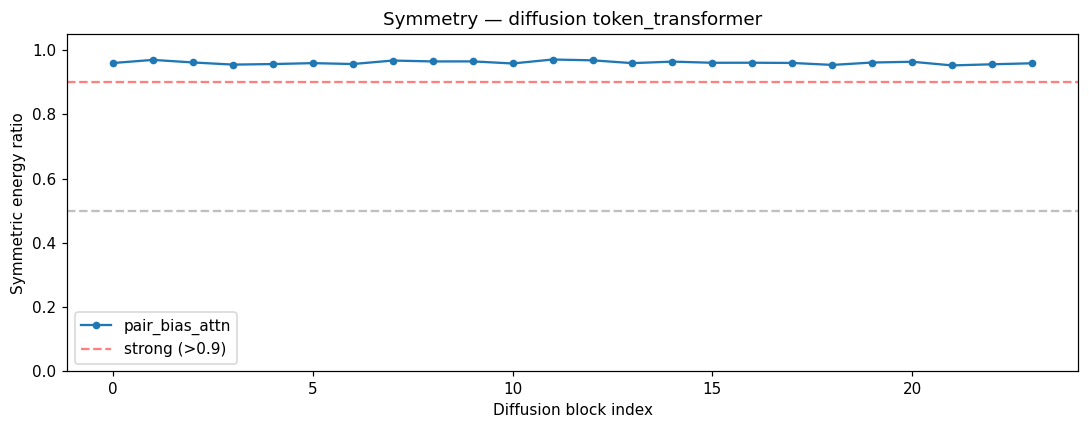

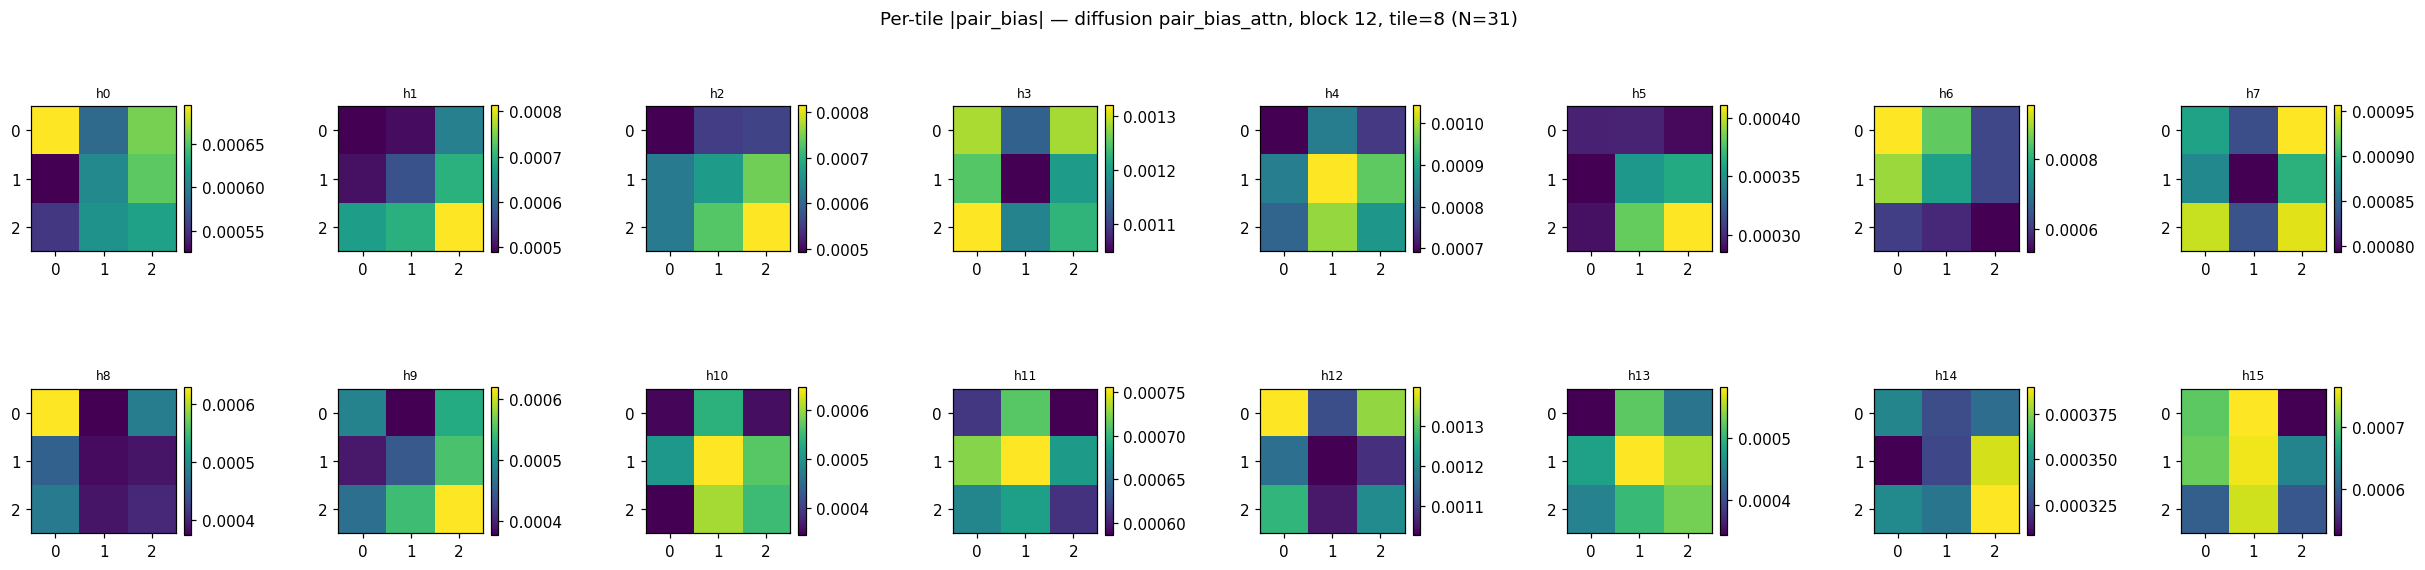

  pair_bias_attn temporal: mean=1.426, median=1.384


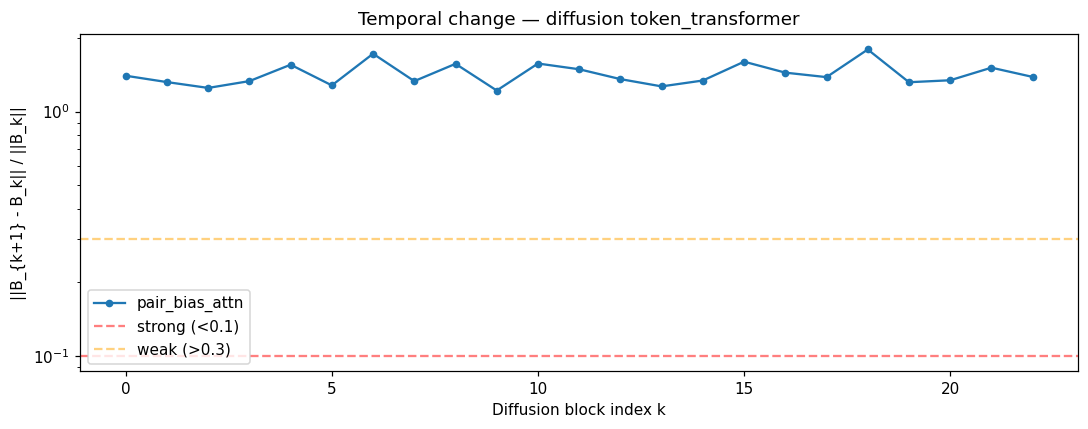

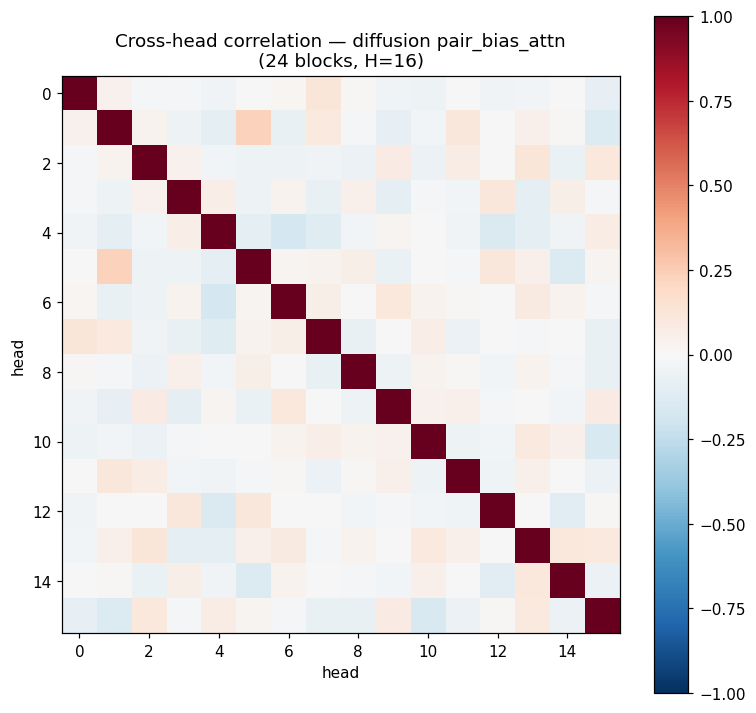

  pair_bias_attn: mean off-diagonal = -0.003

DIFFUSION token_transformer SUMMARY

  pair_bias_attn
  Property                 Value   Threshold   Verdict
  ----------------------------------------------------------
  Symmetry                 0.961   > 0.9      STRONG
  Spatial sparsity         0.000   > 0.30     WEAK
  Temporal delta           1.384   < 0.10     WEAK
  Cross-head corr         -0.003   > 0.80     WEAK


In [32]:
DIFFUSION_SCOPES = {
    "token_transformer": "diffusion_module.token_transformer.layers",
    "atom_encoder":      "diffusion_module.atom_encoder.layers",
    "atom_decoder":      "diffusion_module.atom_decoder.layers",
}

TOKEN_SCOPE = DIFFUSION_SCOPES["token_transformer"]

if TOKEN_SCOPE not in by_scope:
    print("token_transformer not captured. Re-run: bash scripts/capture_pair_bias_structured.sh")
else:
    diff_layer = by_scope[TOKEN_SCOPE]

    print("=" * 78)
    print("DIFFUSION token_transformer — same four metrics")
    print("=" * 78)

    # --- Symmetry plot ---
    fig, ax = plt.subplots(figsize=(10, 4))
    for ltype, blocks in diff_layer.items():
        xs = sorted(blocks.keys())
        ys = [symmetry_ratio(blocks[k]) for k in xs]
        pairs = [(x, y) for x, y in zip(xs, ys) if not np.isnan(y)]
        if not pairs:
            print(f"  {ltype}: all NaN (zero-init)")
            continue
        xp, yp = zip(*pairs)
        ax.plot(xp, yp, "o-", label=ltype, markersize=4)
        print(f"  {ltype} symmetry: mean={np.mean(yp):.3f}")
    ax.axhline(0.5, color="gray", linestyle="--", alpha=0.5)
    ax.axhline(0.9, color="red",  linestyle="--", alpha=0.5, label="strong (>0.9)")
    ax.set_xlabel("Diffusion block index")
    ax.set_ylabel("Symmetric energy ratio")
    ax.set_ylim(0, 1.05)
    ax.legend()
    ax.set_title("Symmetry — diffusion token_transformer")
    plt.tight_layout(); plt.show()

    # --- Tile sparsity heatmap (pair_bias_attn only) ---
    diff_target = "pair_bias_attn" if "pair_bias_attn" in diff_layer else next(iter(diff_layer))
    diff_blocks = diff_layer[diff_target]
    mid_idx = sorted(diff_blocks.keys())[len(diff_blocks) // 2]
    B_mid = diff_blocks[mid_idx]
    N = as_hnn(B_mid).shape[-1]
    ts = choose_tile_size(N)
    tm = tile_magnitude_map(B_mid, tile_size=ts)
    if tm is not None:
        H_plot = tm.shape[0]
        ncols = min(H_plot, 8)
        nrows = (H_plot + ncols - 1) // ncols
        fig, axes = plt.subplots(nrows, ncols, figsize=(2.8 * ncols, 2.8 * nrows), squeeze=False)
        for h in range(H_plot):
            r, c = divmod(h, ncols)
            im = axes[r][c].imshow(tm[h].numpy(), cmap="viridis")
            axes[r][c].set_title(f"h{h}", fontsize=8)
            plt.colorbar(im, ax=axes[r][c], fraction=0.046)
        for h in range(H_plot, nrows * ncols):
            r, c = divmod(h, ncols)
            axes[r][c].axis("off")
        plt.suptitle(f"Per-tile |pair_bias| — diffusion {diff_target}, block {mid_idx}, tile={ts} (N={N})")
        plt.tight_layout(); plt.show()
    else:
        print(f"  N={N}: too small for tile grid.")

    # --- Temporal delta plot ---
    fig, ax = plt.subplots(figsize=(10, 4))
    diff_temporal: dict[str, list[float]] = {}
    for ltype, blocks in diff_layer.items():
        deltas = temporal_deltas(blocks)
        if not deltas:
            continue
        xs, ys = zip(*deltas)
        ax.plot(xs, ys, "o-", label=ltype, markersize=4)
        diff_temporal[ltype] = list(ys)
        print(f"  {ltype} temporal: mean={np.mean(ys):.3f}, median={np.median(ys):.3f}")
    ax.axhline(0.1, color="red",    linestyle="--", alpha=0.5, label="strong (<0.1)")
    ax.axhline(0.3, color="orange", linestyle="--", alpha=0.5, label="weak (>0.3)")
    ax.set_yscale("log")
    ax.set_xlabel("Diffusion block index k")
    ax.set_ylabel("||B_{k+1} - B_k|| / ||B_k||")
    ax.set_title("Temporal change — diffusion token_transformer")
    ax.legend(); plt.tight_layout(); plt.show()

    # --- Cross-head correlation ---
    diff_corr: dict[str, float] = {}
    for ltype, blocks in diff_layer.items():
        corrs = [c for B in blocks.values() for c in [head_correlation_matrix(B)] if c is not None]
        if not corrs:
            print(f"  {ltype}: skipped (all-zero or H<2)")
            diff_corr[ltype] = float("nan")
            continue
        H_min = min(c.shape[0] for c in corrs)
        avg_c = torch.stack([c[:H_min, :H_min] for c in corrs]).mean(0)
        fig, ax = plt.subplots(figsize=(max(4, H_min * 0.35 + 1.5), max(3.5, H_min * 0.35 + 1)))
        im = ax.imshow(avg_c.numpy(), cmap="RdBu_r", vmin=-1, vmax=1)
        plt.colorbar(im, ax=ax)
        ax.set_title(f"Cross-head correlation — diffusion {ltype}\n({len(corrs)} blocks, H={H_min})")
        ax.set_xlabel("head"); ax.set_ylabel("head")
        plt.tight_layout(); plt.show()
        mask = 1 - torch.eye(H_min)
        mean_off = ((avg_c * mask).sum() / mask.sum()).item()
        diff_corr[ltype] = mean_off
        print(f"  {ltype}: mean off-diagonal = {mean_off:.3f}")

    # --- Mini summary for diffusion ---
    print("\n" + "=" * 78)
    print("DIFFUSION token_transformer SUMMARY")
    print("=" * 78)
    for ltype, blocks in diff_layer.items():
        sv = [v for v in (symmetry_ratio(B) for B in blocks.values()) if not np.isnan(v)]
        sym_m = float(np.mean(sv)) if sv else float("nan")
        spv = []
        for B in blocks.values():
            tm2 = tile_magnitude_map(B)
            if tm2 is None: continue
            med = tm2.median()
            if med > 0: spv.append((tm2 < med * 0.1).float().mean().item())
        sp_m = float(np.mean(spv)) if spv else float("nan")
        dv = [d for _, d in temporal_deltas(blocks)]
        dm = float(np.median(dv)) if dv else float("nan")
        oc = diff_corr.get(ltype, float("nan"))
        rows = [
            ("Symmetry",         sym_m, "> 0.9",  classify(sym_m, 0.9,  0.7,  True)),
            ("Spatial sparsity", sp_m,  "> 0.30", classify(sp_m,  0.30, 0.15, True)),
            ("Temporal delta",   dm,    "< 0.10", classify(dm,    0.10, 0.30, False)),
            ("Cross-head corr",  oc,    "> 0.80", classify(oc,    0.80, 0.50, True)),
        ]
        print(f"\n  {ltype}")
        print(f"  {'Property':<22}{'Value':>8}   {'Threshold':<8}   Verdict")
        print(f"  {'-'*58}")
        for n, v, t, vd in rows:
            vs = f"{v:>8.3f}" if not np.isnan(v) else "     N/A"
            print(f"  {n:<22}{vs}   {t:<8}   {vd}")
